In [2]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel

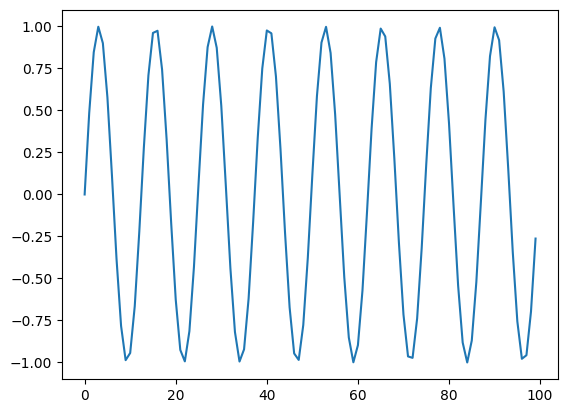

In [3]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.RandomState(0)
data = np.linspace(0, 1, num=1_00).reshape(-1, 1)
target = np.sin(50*data).ravel()

training_sample_indices = rng.choice(np.arange(0, 50), size=40, replace=False)
training_data = data[training_sample_indices]
training_noisy_target = target[training_sample_indices] + 0.5 * rng.randn(
    len(training_sample_indices)
)

plt.plot(target)

In [4]:
from sklearn.gaussian_process.kernels import RBF, WhiteKernel

kernel = RBF(
    length_scale=0.3, length_scale_bounds="fixed"
) + WhiteKernel(1e-1)
gaussian_process = GaussianProcessRegressor(kernel=kernel)
gaussian_process.fit(training_data, training_noisy_target)
mean_predictions_gpr, std_predictions_gpr = gaussian_process.predict(
    data,
    return_std=True,
)

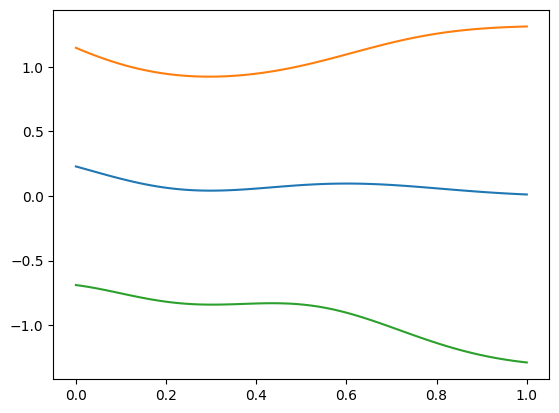

In [5]:
plt.plot(data, mean_predictions_gpr)
plt.plot(data, mean_predictions_gpr + std_predictions_gpr)
plt.plot(data, mean_predictions_gpr - std_predictions_gpr)

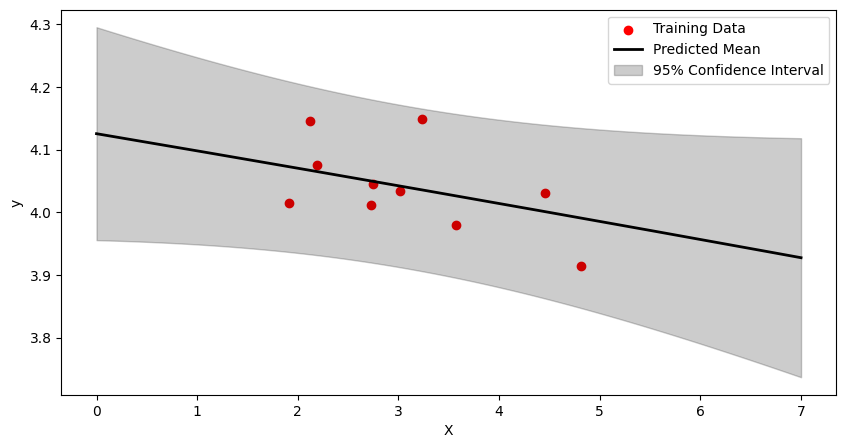

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
from sklearn.model_selection import train_test_split

# Generate sample data
np.random.seed(0)
X = np.sort(5 * np.random.rand(10, 1), axis=0)
y = np.random.normal(0, 0.1, size=10).reshape(-1, 1)
y += 4#np.random.normal(0, 0.1, size=20).reshape(-1, 1)

# Add noise to the data
# Define the kernel (RBF kernel)
kernel = 1.0 * RBF(length_scale=0.1) + WhiteKernel(0.1)

# Create a Gaussian Process Regressor with the defined kernel
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)


# Fit the Gaussian Process model to the training data
gp.fit(X, y)

# Make predictions on the test data
y_pred, sigma = gp.predict(X, return_std=True)

# Visualize the results
x = np.linspace(0, 7, 1000)[:, np.newaxis]
y_mean, y_cov = gp.predict(x, return_cov=True)

plt.figure(figsize=(10, 5))
plt.scatter(X, y, c='r', label='Training Data')
plt.plot(x, y_mean, 'k', lw=2, zorder=9, label='Predicted Mean')
plt.fill_between(x[:, 0], y_mean - 1.96 * np.sqrt(np.diag(y_cov)), y_mean + 1.96 *
                 np.sqrt(np.diag(y_cov)), alpha=0.2, color='k', label='95% Confidence Interval')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

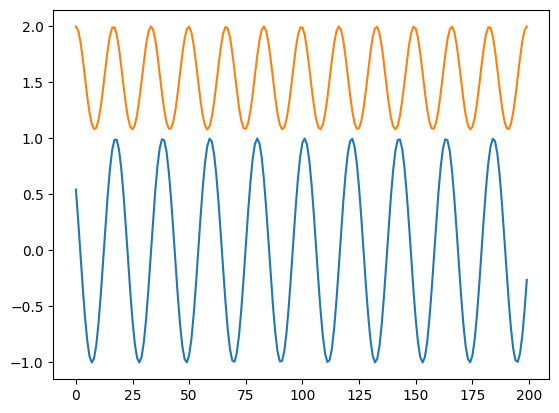

In [30]:
xs = np.linspace(-100, 500, 200)
xm = np.linspace(-100, 500, 200)
fm = 0.1
fc = 0
plt.plot(np.sin(fm*xm))
plt.plot(2*np.cos(2*np.pi * fc * xs + np.sin(0.2*np.pi *fm*xm))) 